# Nominal Flattop Scenario for CENTAUR #

This notebook creates the nominal input files for CENTAUR. An updated TokaMaker installation is needed to run, which is availible here: https://openfusiontoolkit.github.io/OpenFUSIONToolkit/

In [1]:
import os
import sys
import scipy
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

In [2]:
############## LOAD TOKAMAKER LIBRARY
sys.path.append('/Applications/OpenFUSIONToolkit/python')
os.environ['OFT_ROOTPATH'] = '/Applications/OpenFUSIONToolkit/python'
tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))

from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_isoflux, read_eqdsk, create_power_flux_fun

#  Build mesh
plasma_dx = 0.04
coil_dx = 0.08
vv_dx = 0.05
vac_dx = 0.05

# Define limiter and VV geometry

In [3]:
myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:   main
Revision id:          8905cc5
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Fortran input file    = /var/folders/05/5bk04kj15rg64s4vd1hd6r0m0000gn/T/oft_22322/oftpyin
XML input file        = none
Integer Precisions    =    4   8
Float Precisions      =    4   8  10
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------



In [4]:
eq = read_eqdsk('EQLibrary/CENTAUR_08-2025_truncate_false_200x200.geqdsk')

In [5]:
meshname = 'CENTAUR_08-2025_mesh.h5'

mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict = load_gs_mesh(f'{meshname}')
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)

mygs.setup_regions(cond_dict=cond_dict, coil_dict=coil_dict)
mygs.settings.maxits = 200
mygs.setup(order=2, F0=eq['rcentr']*eq['bcentr'])


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  2.998E+01
    # of points  =   19178
    # of edges   =   57093
    # of cells   =   37916
    # of boundary points =     438
    # of boundary edges  =     438
    # of boundary cells  =     438
  Resolution statistics:
    hmin =  5.000E-03
    hrms =  4.508E-02
    hmax =  1.178E-01
  Surface grounded at vertex    1335


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    7.6921000000000003E-002


In [6]:
# DEFINE TARGETS
pax_target = eq['pres'][0]
Ip_target = abs(eq['ip'])
mygs.set_targets(Ip=Ip_target,pax=pax_target)

In [7]:
## DEFINE SHAPE TARGETS

R0 = eq['rcentr']
Z0 = 0
a = 0.72
kappa_flattop = 1.5
delta_flattop = -0.52

xWeight = 50 # targeting weight for x point location
isoWeight = 500 # targeting weight for isoflux shaping points

boundary = create_isoflux(4,R0,0.0,a,kappa_flattop,delta_flattop)

x_points = np.zeros((2,2))
x_points[0,:] = boundary[np.argmin(boundary[:,1]),:]
x_points[1,:] = boundary[np.argmax(boundary[:,1]),:]

x_points[1,0] = x_points[0,0]
x_points[1,1] = -x_points[0,1]

x_weights = xWeight*np.ones(2) # moved to inputs area
mygs.set_saddles(x_points, x_weights)

isoflux_weights = isoWeight*np.ones(len(boundary))
mygs.set_isoflux(boundary, isoflux_weights)

In [8]:
## DEFINE COIL REGULARIZATION MATRIX

coilWeight = 3 # coil current minimization weight in coil regularization matrix

coil_reg_mat = np.zeros((mygs.ncoils+1,mygs.ncoils+1), dtype=np.float64)
targets = np.zeros(mygs.ncoils+1)
coil_weights = coilWeight*0.5*np.ones(mygs.ncoils+1)

# Constrain CS current
coil_reg_mat[0,0] = 1
coil_reg_mat[0,4] = 0
targets[0] = -3E6
targets[4] = -3E6
coil_weights[0] = 5
coil_weights[4] = 5

# Enforce up/down symmetry in PF coils
coil_reg_mat[1,1] = 1
coil_reg_mat[1,5] = -1
coil_reg_mat[2,2] = 1
coil_reg_mat[2,6] = -1
coil_reg_mat[3,3] = 1
coil_reg_mat[3,7] = -1
coil_reg_mat[4,4] = 1

mygs.set_coil_reg(coil_reg_mat, targets, coil_weights)

## SET UPPER AND LOWER COIL CURRENT LIMITS

coil_bounds = {key: [-5e7, 5e7] for key in mygs.coil_sets}
mygs.set_coil_bounds(coil_bounds)

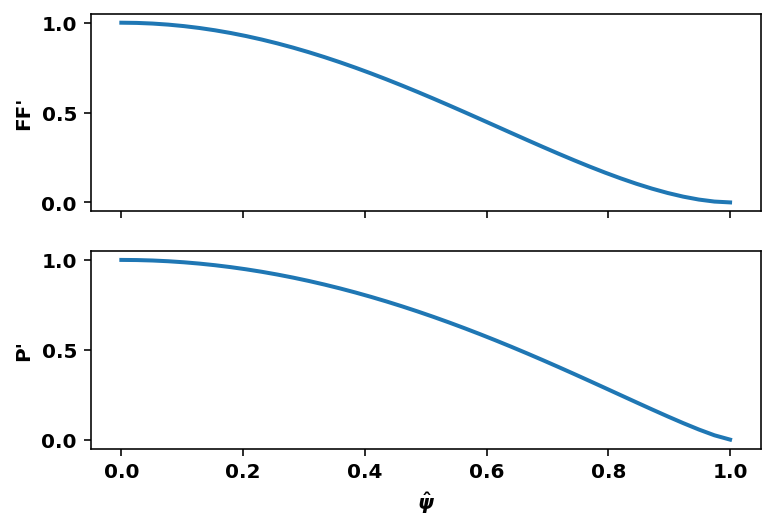

In [9]:
## DEFINE FLUX FUNCTIONS

ffp_prof = create_power_flux_fun(40,2.,1.8) # (num of spline points, alpha, beta)
pp_prof = create_power_flux_fun(40,2,1.25)

fig, ax = plt.subplots(2,1,sharex=True)
# Plot F*F'
ax[0].plot(ffp_prof['x'],ffp_prof['y'])
ax[0].set_ylabel("FF'")
# Plot P'
ax[1].plot(pp_prof['x'],pp_prof['y'])
ax[1].set_ylabel("P'")
_ = ax[-1].set_xlabel(r"$\hat{\psi}$")

mygs.set_profiles(ffp_prof=ffp_prof,pp_prof=pp_prof)

In [10]:
## COMPUTE EQUILIBRIUM

mygs.init_psi(R0,Z0,a,kappa_flattop,delta_flattop)
mygs.solve()

Starting non-linear GS solver
     1 -6.2664E+00  4.7658E+00  3.1567E-01  2.1778E+00 -2.8334E-06 -0.0000E+00
     2  1.6379E+01  2.9987E+00  6.1832E-02  2.1572E+00  4.2433E-05 -0.0000E+00
     3  2.2955E+01  2.5549E+00  2.4168E-02  2.1426E+00 -9.9655E-06 -0.0000E+00
     4  2.5273E+01  2.4024E+00  1.9414E-02  2.1340E+00 -5.5244E-05 -0.0000E+00
     5  2.6121E+01  2.3466E+00  1.2877E-02  2.1293E+00 -7.6213E-05 -0.0000E+00
     6  2.6429E+01  2.3257E+00  7.6318E-03  2.1267E+00  8.9407E-08 -0.0000E+00
     7  2.6534E+01  2.3180E+00  4.2591E-03  2.1253E+00  6.6247E-06 -0.0000E+00
     8  2.6564E+01  2.3152E+00  2.2884E-03  2.1246E+00  9.9830E-06 -0.0000E+00
     9  2.6569E+01  2.3143E+00  1.1958E-03  2.1243E+00  1.1688E-05 -0.0000E+00
    10  2.6566E+01  2.3141E+00  6.1083E-04  2.1241E+00  1.2564E-05 -0.0000E+00
    11  2.6563E+01  2.3141E+00  3.0577E-04  2.1240E+00  1.3012E-05 -0.0000E+00
    12  2.6560E+01  2.3142E+00  1.5016E-04  2.1240E+00  1.3235E-05 -0.0000E+00
    13  2.6558E+01  2.

Text(0, 0.5, 'Z (m)')

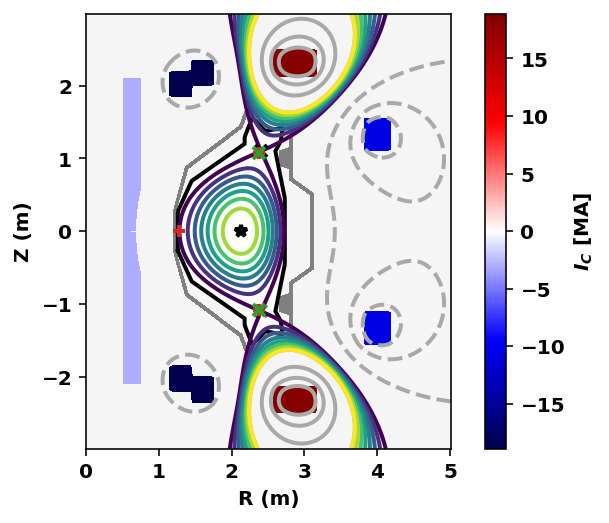

In [11]:
fig, ax = plt.subplots(1,1)

mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_symmap=True,coil_scale=1.E-6,coil_clabel=r'$I_C$ [MA]')
mygs.plot_psi(fig,ax,vacuum_nlevels=4)
mygs.plot_constraints(fig,ax)

ax.set_xlabel('R (m)')
ax.set_ylabel('Z (m)')

## Define full scenario targets
To plan out a full pulse we now define representative time-dependent sequences for all required quantities. In this case we are just doing simple linear ramp-up and ramp-down of 10 ms each with a 40 ms flattop in between. We are assuming a 1 kA plasma after breakdown and are not including more detailed effects like flux consumption associated with breakdown. A simple density evolution is also defined to support evaluation of resistivity from the pressure profile.

In [12]:
Ip_breakdown = 1.E5
beta_breakdown = 0.1
beta_flattop = 1.65
scenario_targets = {
    'time': np.r_[0.0, 20, 30, 35],
    'Ip': np.r_[Ip_breakdown, Ip_target, Ip_target, Ip_breakdown],
    'kappa': np.r_[1.0, kappa_flattop, kappa_flattop, 1.0],
    'delta': np.r_[0.0, delta_flattop, delta_flattop, 0.0],
    'r0': np.r_[2, R0, R0, 2],
    'z0': np.r_[0.0, Z0, Z0, 0.0],
    'beta_approx': np.r_[beta_breakdown, beta_flattop, beta_flattop, beta_flattop*1.25],
    'density': np.r_[2.0E19, 2.7E20, 3.E20, 3.3E20]
}


### Plot scenario targets

In [13]:
# Define helper function for finding approximate limiting minor radius
lim_upper = np.flip(mygs.lim_contour[np.logical_and(mygs.lim_contour[:,0]>0.2,mygs.lim_contour[:,1]>0.06),:], axis=0)
def max_minor_rad(r0,kappa,delta,lim_pad=0.01):
    rmax = max(lim_upper[:,0])
    rmin = min(lim_upper[:,0])
    a_from_r = min(r0 - rmin, rmax - r0)
    r_zmax = r0 + a_from_r * np.cos(np.pi/2.0 + np.arcsin(delta))
    zmax_lim = scipy.interpolate.interp1d(lim_upper[:,0], lim_upper[:,1])(r_zmax) - lim_pad
    a_from_z = zmax_lim / kappa
    return min(a_from_z, a_from_r)

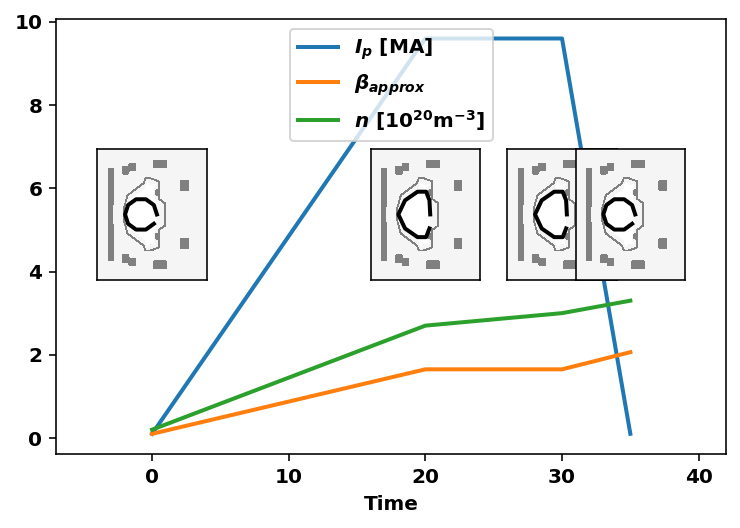

In [14]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(1,1)
ax.plot(scenario_targets['time'],scenario_targets['Ip']/1.E6,label=r'$I_p$ [MA]')
ax.plot(scenario_targets['time'],scenario_targets['beta_approx'],label=r'$\beta_{approx}$')
ax.plot(scenario_targets['time'],scenario_targets['density']/1.E20,label=r'$n$ $[10^{20} $m$^{-3}]$')
t0 = scenario_targets['time'][0] - 0.2*(scenario_targets['time'][-1] - scenario_targets['time'][0])
t1 = scenario_targets['time'][-1] + 0.2*(scenario_targets['time'][-1] - scenario_targets['time'][0])
ax.set_xlim(t0,t1)
ax.legend(loc='upper center')
ax.set_xlabel('Time')

for i, shot_time in enumerate(scenario_targets['time']):
    rel_time = (shot_time-t0)/(t1-t0)
    inset_ax = ax.inset_axes([rel_time-.1, .4, .2, .3])
    mygs.plot_machine(fig, inset_ax, coil_colormap=None, limiter_color=None)
    r0 = np.interp(shot_time,scenario_targets['time'],scenario_targets['r0'])
    z0 = np.interp(shot_time,scenario_targets['time'],scenario_targets['z0'])
    kappa = np.interp(shot_time,scenario_targets['time'],scenario_targets['kappa'])
    delta = np.interp(shot_time,scenario_targets['time'],scenario_targets['delta'])
    a_current = max_minor_rad(r0,kappa,delta)
    isoflux_pts = create_isoflux(10, r0, z0, a_current, kappa, delta)
    inset_ax.plot(isoflux_pts[:,0], isoflux_pts[:,1], c='k')
    inset_ax.set_xticks([]); inset_ax.set_yticks([])

## Compute initial post-breakdown equilibrium
To initialize our scenario we compute an initial post-breakdown equilibrium with $I_p = 1$ kA and $\beta_p \approx = 10$% with a small circular, inboard-limited cross section.

In [15]:
mygs.set_targets(Ip=Ip_breakdown,Ip_ratio=(1.0/beta_breakdown - 1.0))

### Maximize transformer flux
To achieve the longest possible pulse length we want to start the pulse with the higher possible flux on the LCFS, found here manually. Of course, this value depends on your current limits, which are just guesses for now.

In [16]:
## New, more relaxed constraints on the coil currents

coilWeight = 1e-2 # coil current minimization weight in coil regularization matrix

targets = np.zeros(mygs.ncoils+1)
coil_weights = coilWeight*0.5*np.ones(mygs.ncoils+1)

# Constrain CS current
targets[0] = 2E6
targets[4] = 2E6
coil_weights[0] = 5e-2
coil_weights[4] = 5e-2

mygs.set_coil_reg(coil_reg_mat, targets, coil_weights)


In [17]:
#target_psi = 3E+04 # [mWb/rad]
isoflux_pts = create_isoflux(20,1.6,0.0,0.2,1.0,0.0)
mygs.set_isoflux(isoflux_pts, 1.E2*np.ones_like(isoflux_pts[:,0]))    # Target shape
#mygs.set_flux(isoflux_pts, target_psi*np.ones_like(isoflux_pts[:,0])) # Target specific flux value

mygs.init_psi(1.5,0.0,0.2,1.0,0.0)
mygs.solve()

Starting non-linear GS solver
     1  1.6087E+00  3.1386E-02  1.1889E-02  1.6055E+00 -6.1656E-06 -0.0000E+00
     2  1.9206E+00  3.6815E-02  7.7148E-04  1.6052E+00 -4.0990E-06 -0.0000E+00
     3  2.0321E+00  3.8773E-02  1.4421E-03  1.6051E+00 -4.0340E-06 -0.0000E+00
     4  2.0773E+00  3.9544E-02  8.7571E-04  1.6050E+00 -4.1123E-06 -0.0000E+00
     5  2.0960E+00  3.9857E-02  4.3219E-04  1.6050E+00 -4.0066E-06 -0.0000E+00
     6  2.1037E+00  3.9983E-02  1.9532E-04  1.6050E+00 -3.9165E-06 -0.0000E+00
     7  2.1068E+00  4.0033E-02  8.3952E-05  1.6050E+00 -3.8665E-06 -0.0000E+00
     8  2.1080E+00  4.0053E-02  3.4849E-05  1.6050E+00 -3.8480E-06 -0.0000E+00
     9  2.1085E+00  4.0060E-02  1.4099E-05  1.6050E+00 -3.8419E-06 -0.0000E+00
    10  2.1087E+00  4.0063E-02  5.5845E-06  1.6050E+00 -3.8400E-06 -0.0000E+00
    11  2.1088E+00  4.0064E-02  2.1721E-06  1.6050E+00 -3.8394E-06 -0.0000E+00
    12  2.1088E+00  4.0065E-02  8.3106E-07  1.6050E+00 -3.8392E-06 -0.0000E+00
 Timing:  0.7329789999

psi_LCFS =    1.791E+02 [mWb/rad]


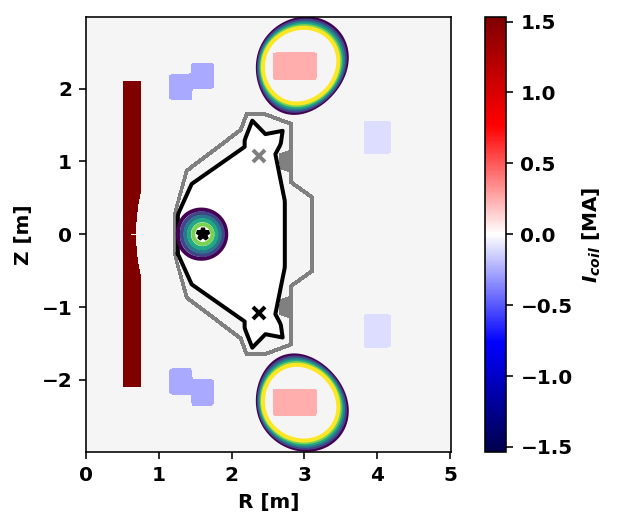

In [18]:
fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_symmap=True,coil_scale=1.0E-6,coil_clabel=r'$I_{coil}$ [MA]')
mygs.plot_psi(fig,ax,xpoint_color='k',vacuum_nlevels=0,plasma_nlevels=6)
ax.set_ylabel('Z [m]')
ax.set_xlabel('R [m]')

lcfs_psi = mygs.psi_bounds[0]
print('psi_LCFS = {0:12.3E} [mWb/rad]'.format(lcfs_psi*1.E3))

## Compute full Centaur pulse
Now we move on to compute equilibria throughout the full plasma pusled defined by the target waveforms above.

### Define resistivity helper functions
In order to capture the flux consumption we need to define resistivity in the plasma, which we do with a simple Spitzer model. Here we define simple helper models that map from the equilibrium pressure profile to a resistivity profile under the assumption of constant density and $T_e/T_i$.

In [19]:
def spitzer_resistivity(n,T):
    def log_lambda(n,T):
        return 24.0-np.log(np.sqrt(n/1.E6)/T)
    return 5.253E-5*log_lambda(n,T)/np.power(T,1.5)

def te_from_p(p,n,te_edge=10.0,ti_frac=0.2):
    from OpenFUSIONToolkit.util import eC
    total_temp = p/(n*eC)
    Te = total_temp/(1.0+ti_frac)
    return Te + te_edge

def coil_vec2dict(self,currents):
    current_array = np.zeros((self.ncoils,), dtype=np.float64)
    for coil_key, coil_current in currents.items():
        current_array[self.coil_sets[coil_key]['id']] = coil_current
    return current_array

Here we demonstrate the use of these functions to compute the loop voltage required to maintain the initial post-breakdown equilibrium.

5.4936 [V]


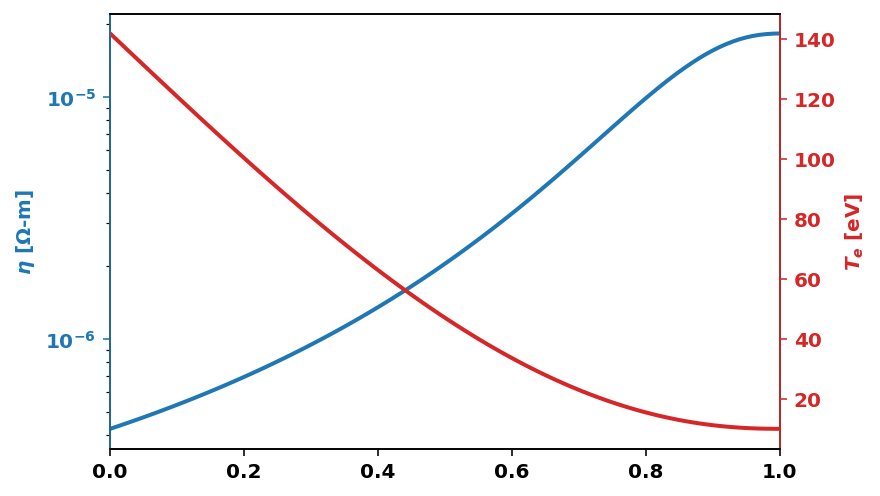

In [20]:
# Get temperature from pressure
psi_prof = np.linspace(0.0,1.0,100)
_,f,fp,p,pp = mygs.get_profiles(psi_prof)
density = scenario_targets['density'][0]
Te = te_from_p(p,density)
eta_prof = spitzer_resistivity(density,Te) # Spitzer resistivity

# Plot temperature and resistivity
fig, ax = plt.subplots(1,1)
ax2 = ax.twinx()
ax.semilogy(psi_prof,eta_prof,'tab:blue')
ax2.plot(psi_prof,Te,'tab:red')
ax.set_ylabel(r'$\eta$ [$\Omega$-m]',color='tab:blue')
ax2.set_ylabel(r'$T_e$ [eV]',color='tab:red')
ax.tick_params(axis='y',color='tab:blue', labelcolor='tab:blue')
ax2.tick_params(color='tab:red', labelcolor='tab:red')
ax2.spines['left'].set_edgecolor('tab:blue')
ax2.spines['right'].set_edgecolor('tab:red')
ax.set_xlim(0.0,1.0)

# Set resistivity and get loop voltage
mygs.set_resistivity({'type': 'linterp', 'x': psi_prof, 'y': eta_prof})
loop_voltage = mygs.calc_loopvoltage()
print('{0:.5} [V]'.format(loop_voltage))

### Compute equilibria
No we can compute equilibria through the pulse by stepping in time. At each point we compute a new equilibrium subject to the target constraints, including an time-varying value of $\psi_{LCFS}$ that is determined by the time-varying loop voltage computed using Spitzer resistivity. Additionally, we also apply a simple regularizatino term that aims to limit changes in coil current between time points, which is a simple proxy for minimizing coil voltages.

In [21]:
# Disable iteration printing in solve
mygs.settings.pm=False
mygs.update_settings()

# Initialize previous step values
prev_coils, _ = mygs.get_coil_currents()
psi_target = mygs.psi_bounds[0]
last_time = 0
dt = 1
nstatus = 10

# Create storage arrays for timeseries data
frames = []
psi_hist = [mygs.get_psi()]
coil_hist = [coil_vec2dict(mygs,prev_coils),]
flux_hist = [[mygs.psi_bounds[0],mygs.psi_bounds[0]],]
vloop_hist = [mygs.calc_loopvoltage()]
volt_hist = []
Lcoils = mygs.get_coil_Lmat()

# Run calculation over scenario
time_points = np.arange(0.0, scenario_targets['time'][-1], dt)
for step, shot_time in enumerate(time_points[1:]):
    # Compute new global targets at current time
    Ip = np.interp(shot_time,scenario_targets['time'],scenario_targets['Ip'])
    beta_approx = np.interp(shot_time,scenario_targets['time'],scenario_targets['beta_approx'])
    
    # Compute new shape targets at current time
    r0 = np.interp(shot_time,scenario_targets['time'],scenario_targets['r0'])
    z0 = np.interp(shot_time,scenario_targets['time'],scenario_targets['z0'])
    kappa = np.interp(shot_time,scenario_targets['time'],scenario_targets['kappa'])
    delta = np.interp(shot_time,scenario_targets['time'],scenario_targets['delta'])
    density = np.interp(shot_time,scenario_targets['time'],scenario_targets['density'])
    a_current = max_minor_rad(r0,kappa,delta)
    
    # Update LCFS target from loop voltage
    dt = shot_time - last_time
    delta_psi = (loop_voltage * dt) / (2 * np.pi)
    psi_target -= delta_psi
    if step % nstatus == 0:
        print(f"Step {step:3d}: psi_target = {psi_target:.2E} Ip={Ip:.2E}, kappa={kappa:.2f}, delta={delta:.2f}, a={a_current:.3f}")
    
    # Set updated targets
    mygs.set_targets(Ip=Ip,Ip_ratio=(1.0/beta_approx - 1.0))
    isoflux_pts = create_isoflux(20, r0, z0, a_current, kappa, delta)
    mygs.set_flux(isoflux_pts, psi_target*np.ones((isoflux_pts.shape[0],)))
    mygs.set_isoflux(isoflux_pts) # By including isoflux pts too, we add weight to making sure the shape is matched in addition to the desired flux
    
    # Update coil regularization using coil currents from previous step
    regularization_terms = []
    for name, coil in mygs.coil_sets.items():
        weight = 1.E-2
        regularization_terms.append(mygs.coil_reg_term({name: 1.0}, target=prev_coils[name], weight=weight))
    mygs.set_coil_reg(reg_terms=regularization_terms)
    
    # Solve for next equilibrium
    try:
        mygs.solve()
    except Exception as e:
        print("  WARNING: Step failed, {0}".format(str(e)))

    # Compute coil voltages
    coil_currents, _ = mygs.get_coil_currents()
    volt_hist.append(np.dot(Lcoils[:-1,:-1],coil_vec2dict(mygs,coil_currents)-coil_vec2dict(mygs,prev_coils))/dt)

    # Save coil currents and boundary flux
    prev_coils = coil_currents.copy()
    coil_hist.append(coil_vec2dict(mygs,coil_currents))
    flux_hist.append([psi_target,mygs.psi_bounds[0]])
    psi_hist.append(mygs.get_psi())
    
    # Update temperature, resistivity, and loop voltage
    psi_prof = np.linspace(0.0, 1.0, 100)
    _, f, fp, p, pp = mygs.get_profiles(psi_prof)
    Te = te_from_p(p, density)
    eta_prof = spitzer_resistivity(density, Te)
    mygs.set_resistivity({'type': 'linterp', 'x': psi_prof, 'y': eta_prof})
    loop_voltage = mygs.calc_loopvoltage()
    vloop_hist.append(loop_voltage)
    
    # Update previous time step
    last_time = shot_time
    
    # Create frame for animation
    fig, ax = plt.subplots(dpi=300,tight_layout=True)
    mygs.plot_machine(fig, ax, coil_colormap='seismic', coil_symmap=True, coil_scale=1e-3, coil_clabel=r'$I_{coil}$ [kA]', limiter_color=None)
    mygs.plot_psi(fig, ax, xpoint_color='k', vacuum_nlevels=0, plasma_nlevels=6)
    ax.plot(isoflux_pts[:, 0], isoflux_pts[:, 1], color='tab:red', label="Target LCFS")
    ax.set_title(r'$I_p$ ={0:4.0F} kA, $V_{{\phi}}$ ={1:4.2F} V, $t$ ={2:4.0F} ms'.format(Ip/1.E3,loop_voltage,shot_time*1.E3))
    ax.legend()
    ax.set_ylabel('Z [m]')
    ax.set_xlabel('R [m]')
    fig.canvas.draw()
    image = np.array(fig.canvas.renderer.buffer_rgba())
    frames.append(image)
    plt.close(fig)

# Reenable iteration plotting 
mygs.settings.pm=True
mygs.update_settings()

Step   0: psi_target = -6.95E-01 Ip=5.75E+05, kappa=1.02, delta=-0.03, a=0.730
Step  10: psi_target = -1.01E+00 Ip=5.32E+06, kappa=1.27, delta=-0.29, a=0.730
Step  20: psi_target = -1.06E+00 Ip=9.60E+06, kappa=1.50, delta=-0.52, a=0.730
Step  30: psi_target = -1.11E+00 Ip=7.70E+06, kappa=1.40, delta=-0.42, a=0.730


### Show animation of scenario


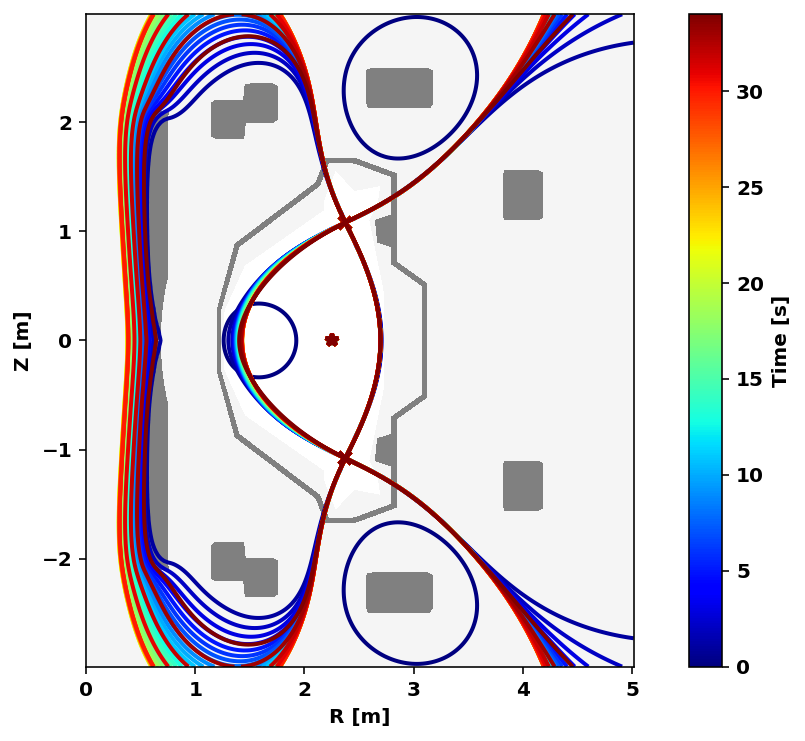

In [22]:
# plot evolution of flux surfaces
fig, ax = plt.subplots(1,1, figsize=(10, 6))
mygs.plot_machine(fig,ax,limiter_color=None)
cmap = plt.get_cmap('jet')
colors = cmap(np.linspace(0, 1, len(psi_hist)))
x=np.linspace(0.0,2*np.pi,100)
for i, result in enumerate(psi_hist):
    try:
        mygs.plot_psi(fig,ax,psi=result,plasma_levels=[1.0],plasma_color=[colors[i]],vacuum_nlevels=0,xpoint_color=colors[i],opoint_color=colors[i])
    except Exception:
        print(i)
        pass

import matplotlib as mpl
norm = mpl.colors.Normalize(vmin=0.0, vmax=max(time_points))
ax.set_xlabel('R [m]')
ax.set_ylabel('Z [m]')
#ax.plot(boundary[:,0], boundary[:,1], 'k.')
_ = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),ax=ax,label='Time [s]')

plt.show()

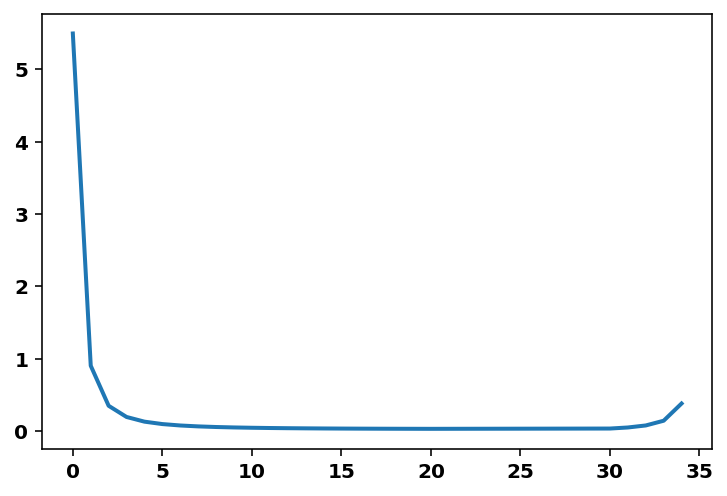

In [23]:
plt.plot(vloop_hist)

### Compare target and realized $\psi_{LCFS}$

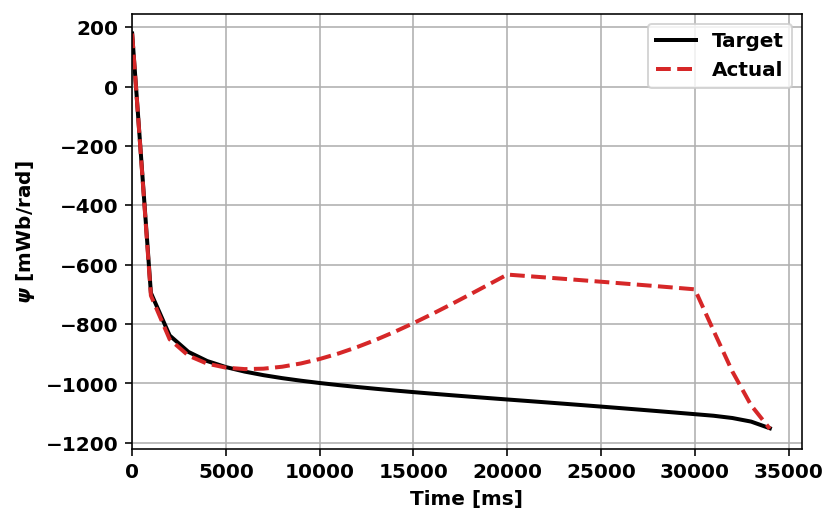

In [24]:
flux_hist = np.array(flux_hist)
fig, ax = plt.subplots(1,1)
ax.plot(time_points*1.E3,flux_hist[:,0]*1.E3,'k',label=r'Target')
ax.plot(time_points*1.E3,flux_hist[:,1]*1.E3,'--',color='tab:red',label=r'Actual')
ax.grid(True)
ax.set_xlim(left=0.0)
ax.set_xlabel('Time [ms]')
ax.set_ylabel(r'$\psi$ [mWb/rad]')
_ = ax.legend()

### Plot coil currents

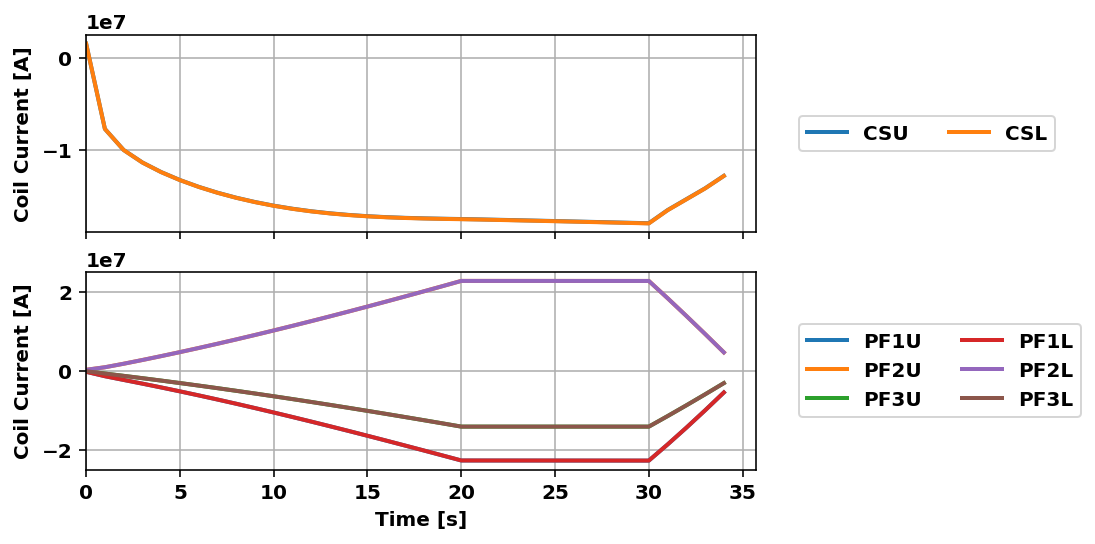

In [25]:
coil_hist = np.array(coil_hist)
fig, ax = plt.subplots(2,1,sharex=True)
for name, coil in mygs.coil_sets.items():
    if name.startswith('CS'):
        ax[0].plot(time_points,coil_hist[:,coil['id']],label=name)
    if name.startswith('PF'):
        ax[1].plot(time_points,coil_hist[:,coil['id']],label=name)
for ax_tmp in ax:
    ax_tmp.grid(True)
    ax_tmp.set_xlim(left=0.0)
    ax_tmp.set_ylabel('Coil Current [A]')
    ax_tmp.legend(ncols=2,loc='center left',bbox_to_anchor=(1.05, 0.5))
_ = ax[-1].set_xlabel('Time [s]')

### Plot coil voltages

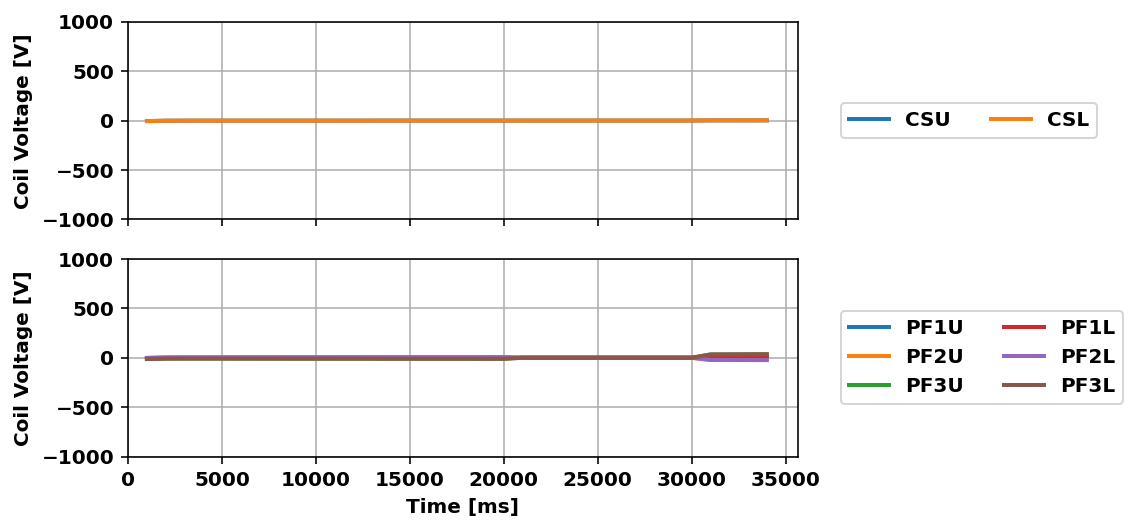

In [26]:
volt_hist = np.array(volt_hist)
fig, ax = plt.subplots(2,1,sharex=True)
for name, coil in mygs.coil_sets.items():
    if name.startswith('CS'):
        ax[0].plot(time_points[1:]*1.E3,volt_hist[:,coil['id']],label=name)
    if name.startswith('PF'):
        ax[1].plot(time_points[1:]*1.E3,volt_hist[:,coil['id']],label=name)
for ax_tmp in ax:
    ax_tmp.grid(True)
    ax_tmp.set_xlim(left=0.0)
    ax_tmp.set_ylim(-1.E3,1.E3)
    ax_tmp.set_ylabel('Coil Voltage [V]')
    ax_tmp.legend(ncols=2,loc='center left',bbox_to_anchor=(1.05, 0.5))
_ = ax[-1].set_xlabel('Time [ms]')